# CSSD 2231 Project

Below is a code implementation and a report on the Adult dataset from the 1990 US Census, predicting whether an individual has an income below or equal to $50K or above.

The dataset has a total of 14 features, excluding the target feature of this report, income. It has an approximate of 33 000 records.

The models used for this dataset are of the classification variant, namely Logistic Regression and Random Forest.

This report is seperated into two sections:
- Code Implementation
- Report Generation
- Result Interpretation
- Limitations
- Ethical Considerations
- Conclusion

The code implementation starts from the next cell.

# Necessary Libraries

Importing the following libraries:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- Tuple

In [1]:
!pip install xgboost

In [2]:
from typing import Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
from itertools import combinations

# Data Retrieval

The function of the following methods:
- read_from_csv_file, reads data from csv dataset file while removing rows with missing values.
- preprocess_data, cleans data columns by making them lower case and stripping white space for further use.

In [3]:
"""Read data from CSV file separated by tabs."""
def read_from_csv_file(file: str) -> pd.DataFrame:
    return pd.read_csv(file, na_values=["?", " ?"])

"""Clean column names, drop rows with missing values."""
def preprocess_data(data: pd.DataFrame) -> pd.DataFrame:
    data.columns = data.columns.str.strip().str.lower()
    data = data.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
    
    data.dropna(inplace=True)
    
    return data

# Data Splitting and Scaling

The functions of the following methods:
- split_features_target, splits target feature, income, from all others, encodes income to 0 and 1, and one-hot encode categorical features so models interpret them.
- split_train_test, splits dataset into training data and testing data.
- scale_features, scales features using StandardScaler so models can compare numerical values more feasibly.

In [4]:
"""Seperate features from target value, encode target to 0 and 1, handle categorical values."""
def split_features_target(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    X = data.drop("income", axis=1)
    y = data["income"].str.strip().map({"<=50K": 0, ">50K": 1})
    
    X = pd.get_dummies(X, drop_first=True)
    return X, y

"""Split dataset into train and test sets."""
def split_train_test(X: pd.DataFrame, y: pd.Series, test_size=0.2, random_state=42) -> Tuple:
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

"""Standardize features."""
def scale_features(X_train: pd.DataFrame, X_test: pd.DataFrame) -> Tuple:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled

# Visualization Helpers

In [5]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def plot_pr_roc(y_test, y_probs, title_prefix="Model"):
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC Curve")
    plt.legend()
    plt.show()

def plot_feature_distributions(data):
    numeric_features = ["age", "hours-per-week", "education-num"]

    for feature in numeric_features:
        if feature in data.columns:
            plt.figure()
            sns.boxplot(x="income", y=feature, data=data)
            plt.title(f"{feature} vs Income")
            plt.show()

def plot_correlation_heatmap(data):
    numeric_data = data.select_dtypes(include=["int64", "float64"])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.show()

def get_metrics(y_test, y_pred):
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

# Model Training

The functions of the following methods:
- train_logistic_regression, trains a logistic regression model given a set of training data implementing class balancing.
- train_random_forest, trains a random forest model given a set of training data implementing class balancing.

In [6]:
"""Train Logistic Regression Model."""
def train_logistic_regression(X_train, y_train, max_iter=1000) -> LogisticRegression:
    model = LogisticRegression(
        max_iter=max_iter, 
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    
    return model

"""Train Random Forest Model."""
def train_random_forest(X_train, y_train, n_estimators=100, max_depth=None) -> RandomForestClassifier:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    
    return model

# Report Generation

The generate_report function below does the following:
- Reads and preprocesses data from Adult dataset.
- Visualizes income class distribution (<=50K vs >50K).
- Seperates target feature from all others, encodes and scales each feature.
- All of the above is done for 4 models:
  Baseline Logistic Regression (No dropped features), Best Logistic Regression Model, Baseline Random Forest (No dropped features), Best Random Forest Model
- Generates accuracy scores, classification reports and a list of most important features for each model.
- Compares each model by accuracy and gives a final verdict.

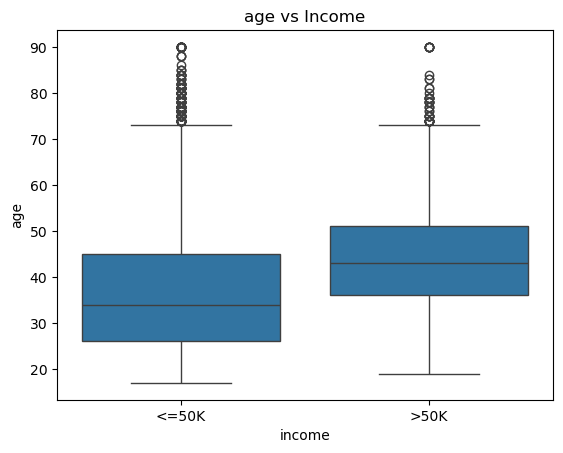

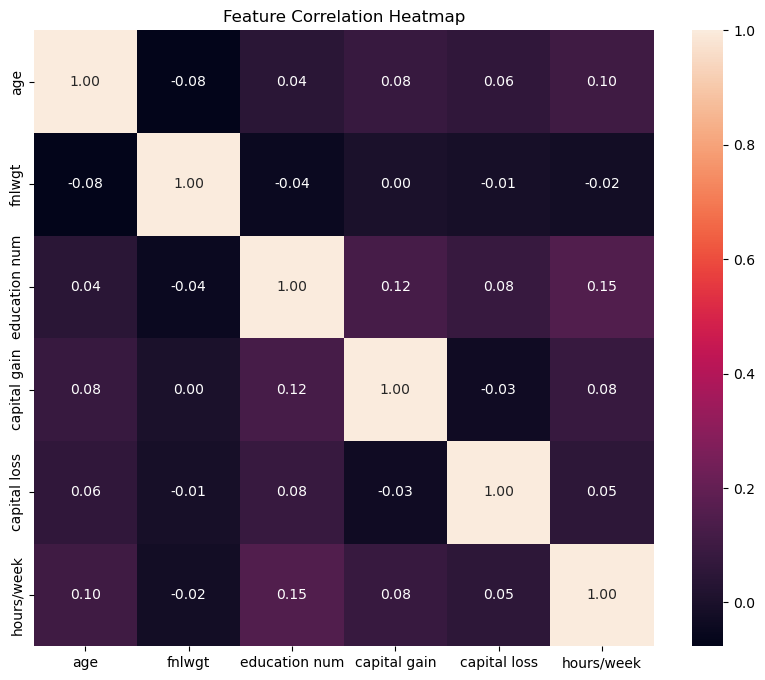

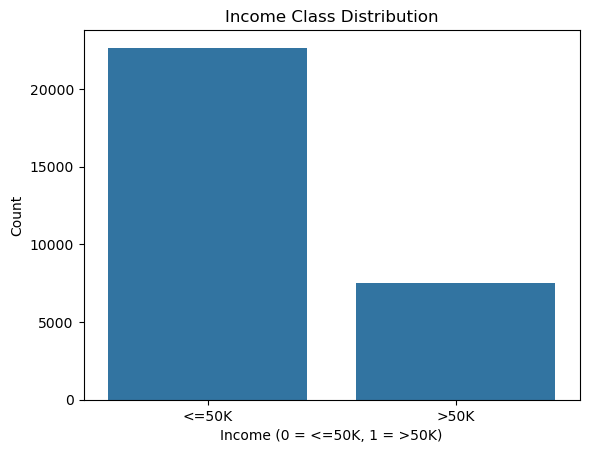


===== Logistic Regression Model (Baseline) =====
Accuracy: 0.8045748383888612
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4531
           1       0.57      0.83      0.68      1502

    accuracy                           0.80      6033
   macro avg       0.75      0.81      0.77      6033
weighted avg       0.84      0.80      0.81      6033



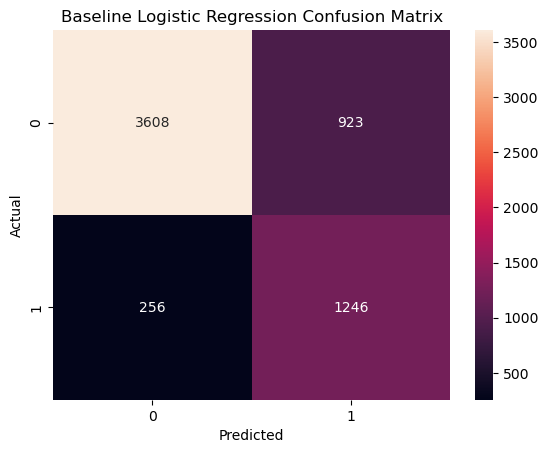

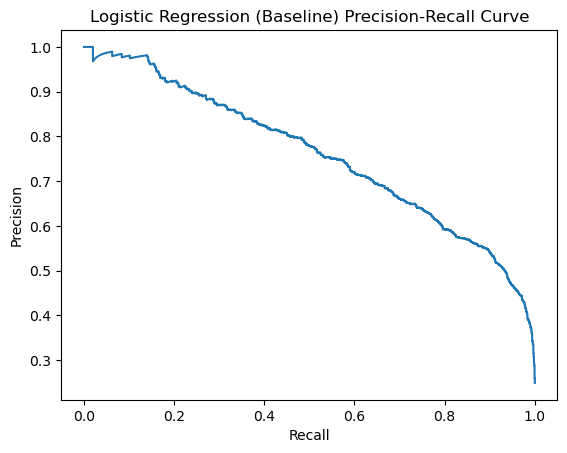

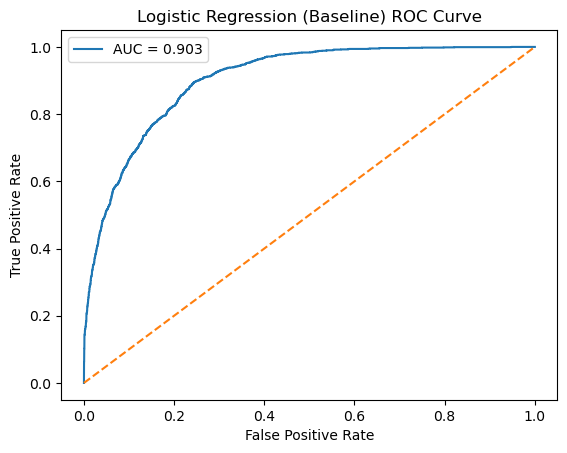

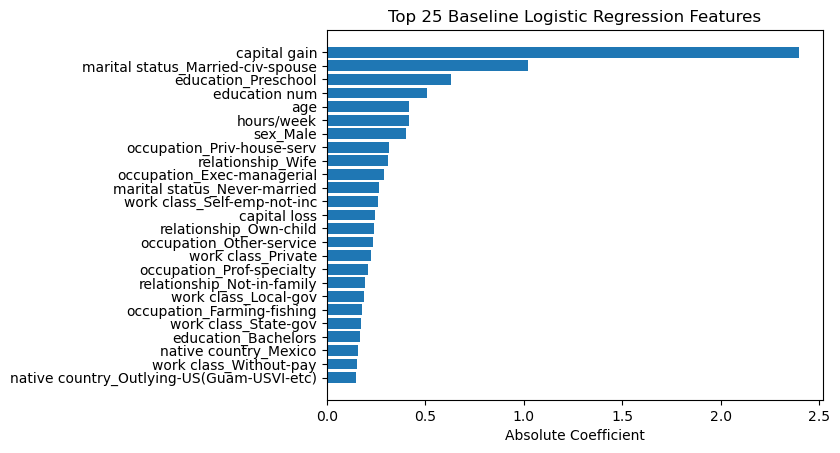


===== Logistic Regression Model (Best Model) =====
Accuracy: 0.8113707939665175
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      4531
           1       0.58      0.84      0.69      1502

    accuracy                           0.81      6033
   macro avg       0.76      0.82      0.78      6033
weighted avg       0.85      0.81      0.82      6033



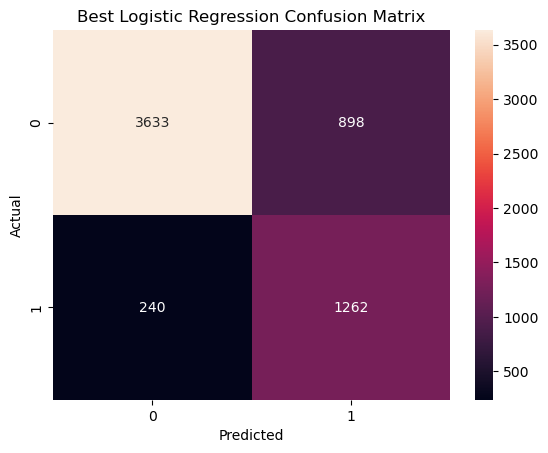

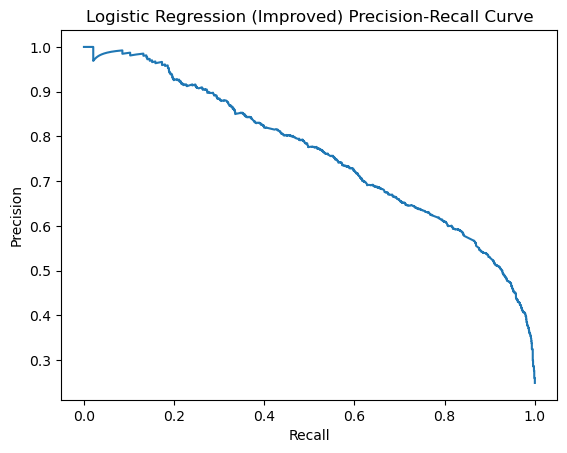

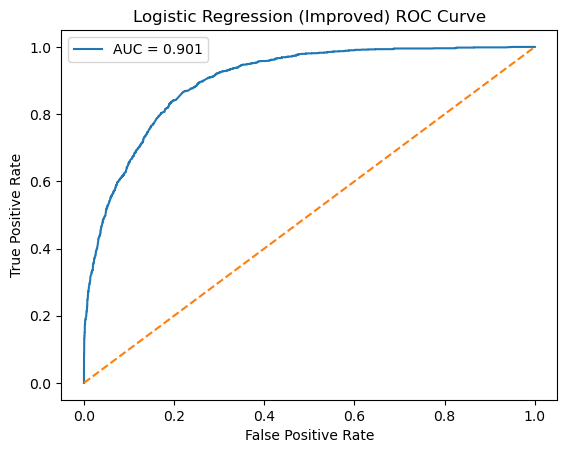

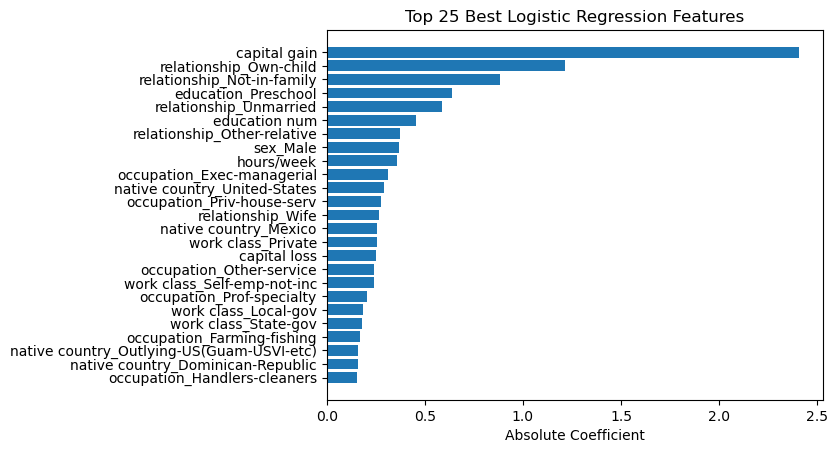


===== Random Forest (Baseline) =====
Accuracy: 0.8483341621084037
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4531
           1       0.73      0.62      0.67      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.79      6033
weighted avg       0.84      0.85      0.84      6033



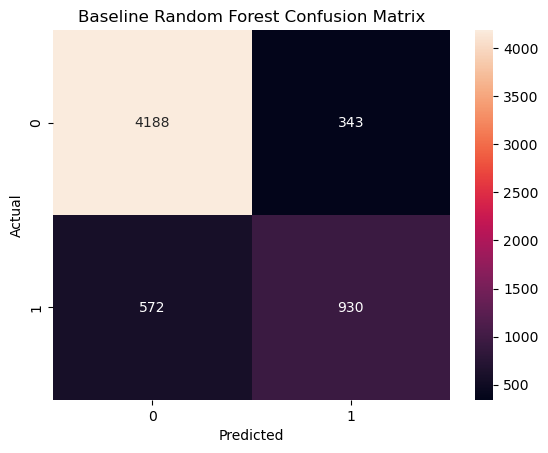

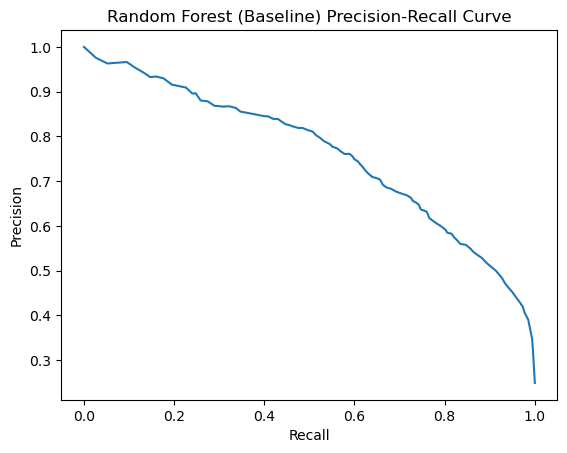

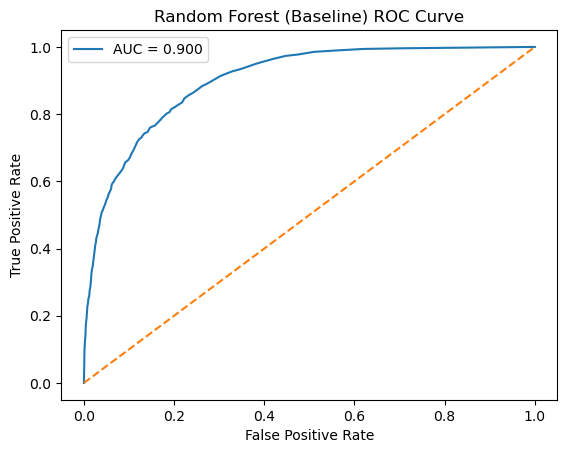

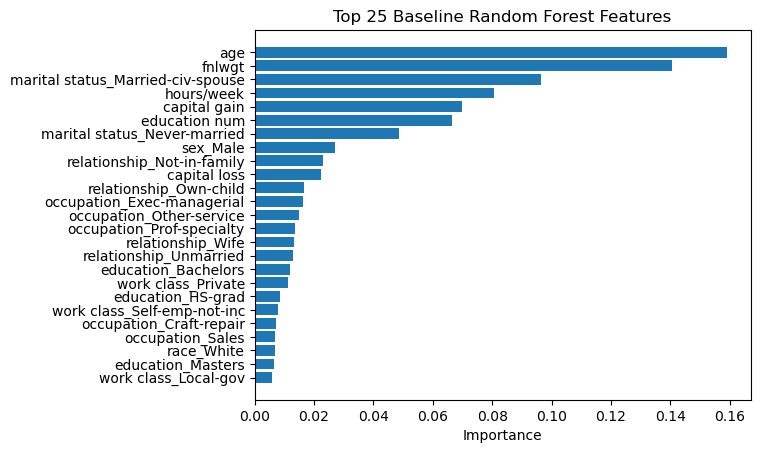


===== Random Forest (Best Model) =====
Accuracy: 0.8516492623901873
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4531
           1       0.74      0.62      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



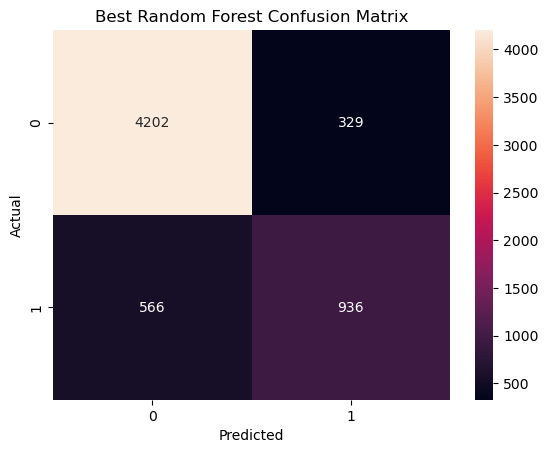

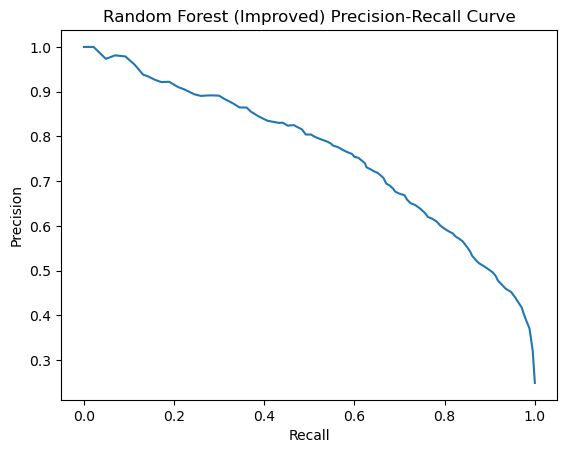

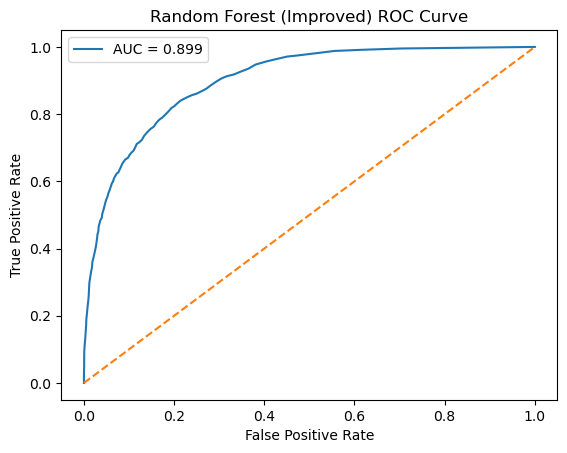

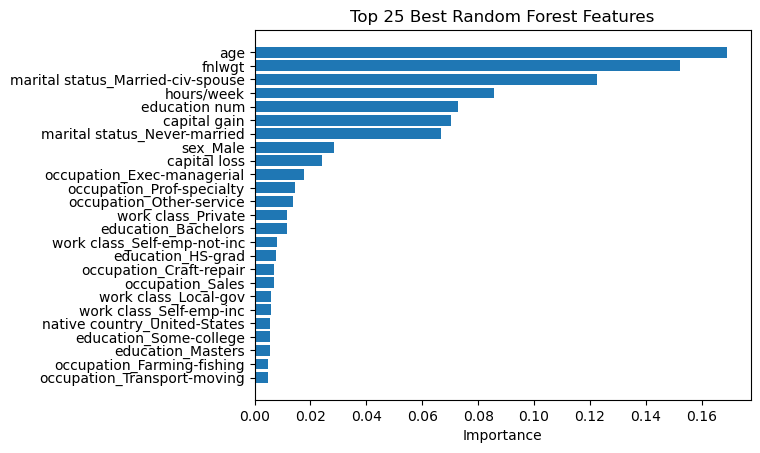

[0]	validation_0-logloss:0.45282
[1]	validation_0-logloss:0.40238
[2]	validation_0-logloss:0.37218
[3]	validation_0-logloss:0.35128
[4]	validation_0-logloss:0.33852
[5]	validation_0-logloss:0.32837
[6]	validation_0-logloss:0.32147
[7]	validation_0-logloss:0.31561
[8]	validation_0-logloss:0.31022
[9]	validation_0-logloss:0.30758
[10]	validation_0-logloss:0.30492
[11]	validation_0-logloss:0.30287
[12]	validation_0-logloss:0.30173
[13]	validation_0-logloss:0.29992
[14]	validation_0-logloss:0.29925
[15]	validation_0-logloss:0.29665
[16]	validation_0-logloss:0.29549
[17]	validation_0-logloss:0.29492
[18]	validation_0-logloss:0.29315
[19]	validation_0-logloss:0.29311
[20]	validation_0-logloss:0.29203
[21]	validation_0-logloss:0.29096
[22]	validation_0-logloss:0.29073
[23]	validation_0-logloss:0.29064
[24]	validation_0-logloss:0.29025
[25]	validation_0-logloss:0.28941
[26]	validation_0-logloss:0.28880
[27]	validation_0-logloss:0.28868
[28]	validation_0-logloss:0.28821
[29]	validation_0-loglos

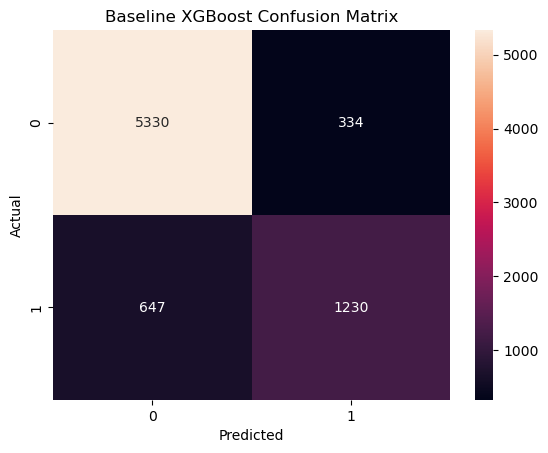

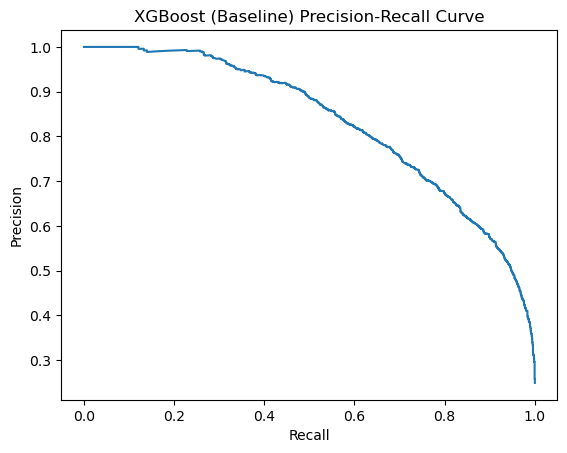

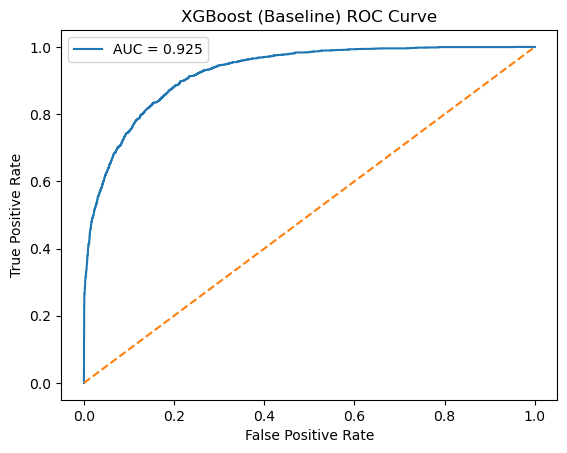

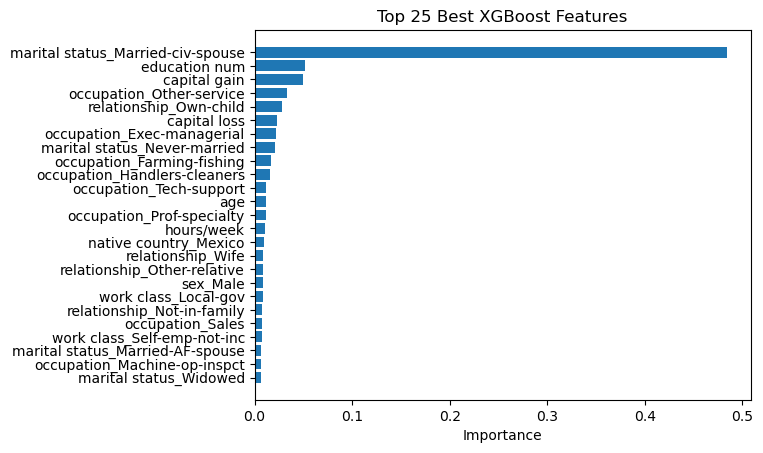


===== XGBoost (Best Model) =====
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8724307121071476
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      5664
           1       0.78      0.67      0.72      1877

    accuracy                           0.87      7541
   macro avg       0.84      0.81      0.82      7541
weighted avg       0.87      0.87      0.87      7541



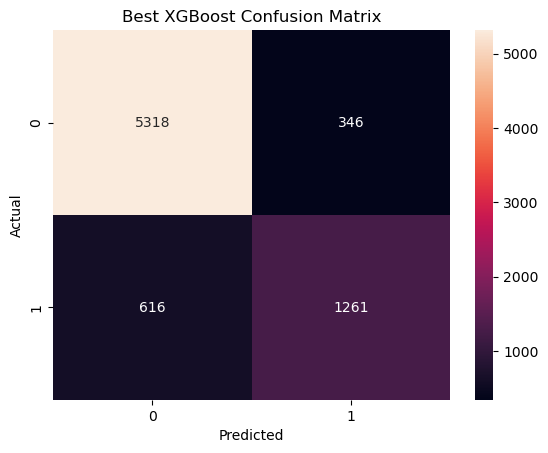

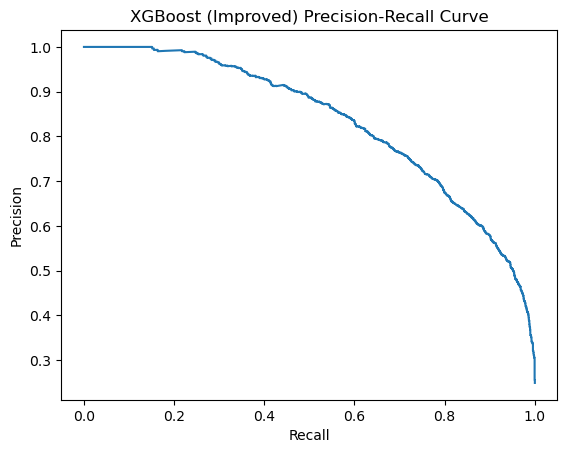

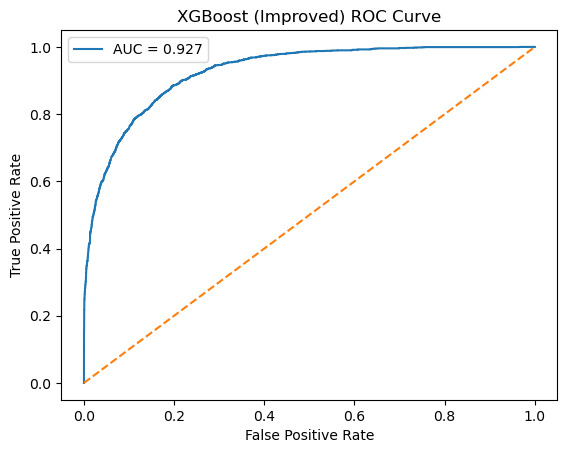

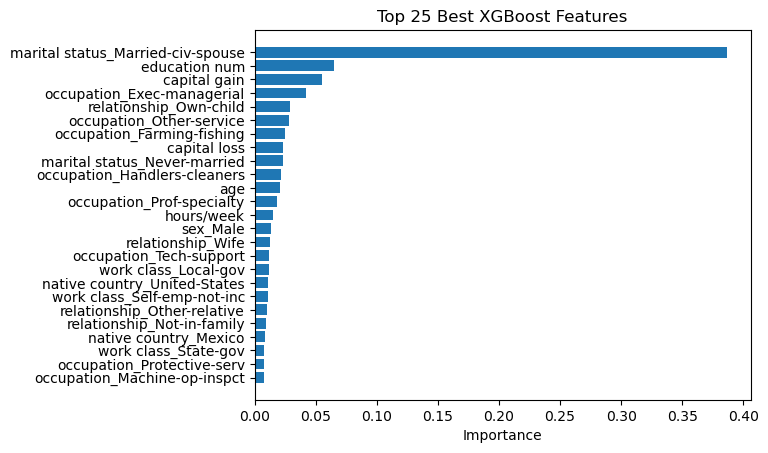


===== Model Comparison =====
Baseline Logistic Regression Accuracy: 0.8045748383888612
Improved Logistic Regression Accuracy: 0.8113707939665175
Baseline Random Forest Accuracy: 0.8483341621084037
Improved Random Forest Accuracy: 0.8516492623901873
Baseline XGBoost Accuracy: 0.8699111523670601
Improved XGBoost Accuracy: 0.8724307121071476


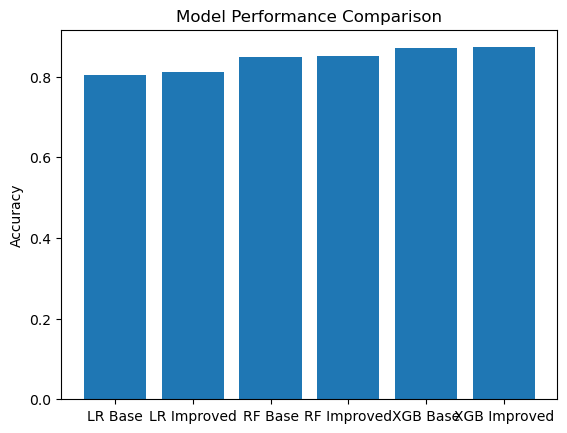


Best Model: XGBoost Best with accuracy 0.8724


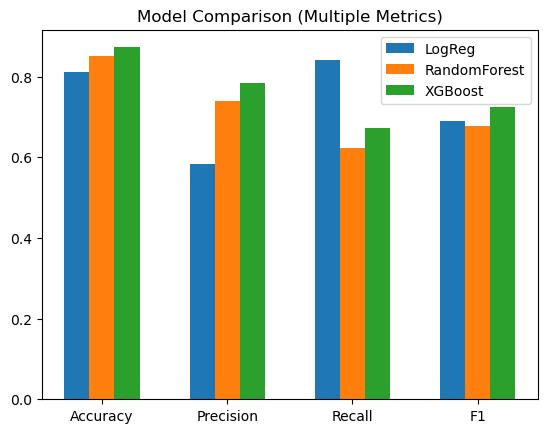

In [7]:
"""Generate Model report."""
def generate_report(csv_file: str) -> str:

    # =====================================================
    # 1. Logistic Regression (Baseline)
    # =====================================================
    
    #Load and preprocess data.
    data = read_from_csv_file(csv_file)
    pre_processed_data = preprocess_data(data)
    plot_feature_distributions(pre_processed_data)
    plot_correlation_heatmap(pre_processed_data)

    # Dataset Overview
    plt.figure()
    sns.countplot(x=pre_processed_data["income"])
    plt.title("Income Class Distribution")
    plt.xlabel("Income (0 = <=50K, 1 = >50K)")
    plt.ylabel("Count")
    plt.show()
    
    X, y = split_features_target(pre_processed_data)
    X_train, X_test, y_train, y_test = split_train_test(X, y)

    # Scale features.
    X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

    # Train model.
    logistic_regression_model = train_logistic_regression(X_train_scaled, y_train)

    print("\n===== Logistic Regression Model (Baseline) =====")
    logistic_regression_accuracy = logistic_regression_model.score(X_test_scaled, y_test)
    print("Accuracy:", logistic_regression_accuracy)

    logistic_regression_y_pred = logistic_regression_model.predict(X_test_scaled)

    lr_base_y_test = y_test
    lr_base_y_pred = logistic_regression_y_pred

    # Classification Report.
    print(classification_report(y_test, logistic_regression_y_pred))

    # Confusion Matrix Visualization.
    logistic_regression_confusion_matrix = confusion_matrix(y_test, logistic_regression_y_pred)
    plt.figure()
    sns.heatmap(logistic_regression_confusion_matrix, annot=True, fmt="d")
    plt.title("Baseline Logistic Regression Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    logistic_regression_y_probs = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
    plot_pr_roc(y_test, logistic_regression_y_probs, "Logistic Regression (Baseline)")

    # Feature Importance.
    coefs = logistic_regression_model.coef_[0]
    logistic_regression_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "coefficients": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values(by="abs_coef", ascending=False)
    logistic_regression_most_important = logistic_regression_importance_list.head(25)

    plt.figure()
    plt.barh(
        logistic_regression_most_important["feature"], 
        logistic_regression_most_important["abs_coef"]
    )
    plt.title("Top 25 Baseline Logistic Regression Features")
    plt.xlabel("Absolute Coefficient")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 2. Logistic Regression (Best Model)
    # =====================================================

    # Load and preprocess data.
    data = read_from_csv_file(csv_file)
    pre_processed_data = preprocess_data(data)
    pre_processed_data = pre_processed_data.drop(["age", "fnlwgt", "marital status", "race"], axis=1)

    X, y = split_features_target(pre_processed_data)
    X_train, X_test, y_train, y_test = split_train_test(X, y)

    # Scale features.
    X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

    # Train model.
    logistic_regression_model = train_logistic_regression(X_train_scaled, y_train)

    print("\n===== Logistic Regression Model (Best Model) =====")
    improved_logistic_regression_accuracy = logistic_regression_model.score(X_test_scaled, y_test)
    print("Accuracy:", improved_logistic_regression_accuracy)

    logistic_regression_y_pred = logistic_regression_model.predict(X_test_scaled)

    lr_best_y_test = y_test
    lr_best_y_pred = logistic_regression_y_pred

    # Classification Report.
    print(classification_report(y_test, logistic_regression_y_pred))

    # Confusion Matrix Visualization.
    logistic_regression_confusion_matrix = confusion_matrix(y_test, logistic_regression_y_pred)
    plt.figure()
    sns.heatmap(logistic_regression_confusion_matrix, annot=True, fmt="d")
    plt.title("Best Logistic Regression Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    logistic_regression_y_probs = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
    plot_pr_roc(y_test, logistic_regression_y_probs, "Logistic Regression (Improved)")

    # Feature Importance.
    coefs = logistic_regression_model.coef_[0]
    logistic_regression_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "coefficients": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values(by="abs_coef", ascending=False)
    logistic_regression_most_important = logistic_regression_importance_list.head(25)

    plt.figure()
    plt.barh(
        logistic_regression_most_important["feature"], 
        logistic_regression_most_important["abs_coef"]
    )
    plt.title("Top 25 Best Logistic Regression Features")
    plt.xlabel("Absolute Coefficient")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 3. Random Forest (Baseline)
    # =====================================================

    # Load and preprocess data.
    data = read_from_csv_file(csv_file)
    pre_processed_data = preprocess_data(data)

    X, y = split_features_target(pre_processed_data)
    X_train, X_test, y_train, y_test = split_train_test(X, y)

    # Train model.
    random_forest_model = train_random_forest(X_train, y_train)

    print("\n===== Random Forest (Baseline) =====")
    random_forest_accuracy = random_forest_model.score(X_test, y_test)
    print("Accuracy:", random_forest_accuracy)

    random_forest_y_pred = random_forest_model.predict(X_test)

    rf_base_y_test = y_test
    rf_base_y_pred = random_forest_y_pred

    # Classification Report.
    print(classification_report(y_test, random_forest_y_pred))

    # Confusion Matrix Vsualization.
    random_forest_confusion_matrix = confusion_matrix(y_test, random_forest_y_pred)
    plt.figure()
    sns.heatmap(random_forest_confusion_matrix, annot=True, fmt="d")
    plt.title("Baseline Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    random_forest_y_probs = random_forest_model.predict_proba(X_test)[:, 1]
    plot_pr_roc(y_test, random_forest_y_probs, "Random Forest (Baseline)")

    # Feature Importance.
    random_forest_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "importance": random_forest_model.feature_importances_
    }).sort_values(by="importance", ascending=False)
    random_forest_most_important = random_forest_importance_list.head(25)

    plt.figure()
    plt.barh(
        random_forest_most_important["feature"], 
        random_forest_most_important["importance"]
    )
    plt.title("Top 25 Baseline Random Forest Features")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 4. Random Forest (Best Model)
    # =====================================================

    # Load and preprocess data.
    data = read_from_csv_file(csv_file)
    pre_processed_data = preprocess_data(data)
    pre_processed_data = pre_processed_data.drop(["relationship", "race"], axis=1)

    X, y = split_features_target(pre_processed_data)
    X_train, X_test, y_train, y_test = split_train_test(X, y)

    # Train model.
    random_forest_model = train_random_forest(X_train, y_train)

    print("\n===== Random Forest (Best Model) =====")
    improved_random_forest_accuracy = random_forest_model.score(X_test, y_test)
    print("Accuracy:", improved_random_forest_accuracy)

    random_forest_y_pred = random_forest_model.predict(X_test)

    rf_best_y_test = y_test
    rf_best_y_pred = random_forest_y_pred

    # Classification Report.
    print(classification_report(y_test, random_forest_y_pred))

    # Confusion Matrix Vsualization.
    random_forest_confusion_matrix = confusion_matrix(y_test, random_forest_y_pred)
    plt.figure()
    sns.heatmap(random_forest_confusion_matrix, annot=True, fmt="d")
    plt.title("Best Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    random_forest_y_probs = random_forest_model.predict_proba(X_test)[:, 1]
    plot_pr_roc(y_test, random_forest_y_probs, "Random Forest (Improved)")

    # Feature Importance.
    random_forest_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "importance": random_forest_model.feature_importances_
    }).sort_values(by="importance", ascending=False)
    random_forest_most_important = random_forest_importance_list.head(25)

    plt.figure()
    plt.barh(
        random_forest_most_important["feature"], 
        random_forest_most_important["importance"]
    )
    plt.title("Top 25 Best Random Forest Features")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 5. XGBoost (Baseline)
    # =====================================================

    # Load and preprocess data.
    data = read_from_csv_file(csv_file)
    pre_processed_data = preprocess_data(data)

    X, y = split_features_target(pre_processed_data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=94)

    # Train model.
    xg_boost_model = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)
    xg_boost_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

    print("\n===== XGBoost (Baseline) =====")
    xgb_accuracy = xg_boost_model.score(X_test, y_test)
    print("Accuracy:", xgb_accuracy)

    xgb_y_pred = xg_boost_model.predict(X_test)

    xgb_base_y_test = y_test
    xgb_base_y_pred = xgb_y_pred

    # Classification Report.
    print(classification_report(y_test, xgb_y_pred))

    # Confusion Matrix Vsualization.
    xgb_confusion_matrix = confusion_matrix(y_test, xgb_y_pred)
    plt.figure()
    sns.heatmap(xgb_confusion_matrix, annot=True, fmt="d")
    plt.title("Baseline XGBoost Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    xgb_y_probs = xg_boost_model.predict_proba(X_test)[:, 1]
    plot_pr_roc(y_test, xgb_y_probs, "XGBoost (Baseline)")

    # Feature Importance
    xgb_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "importance": xg_boost_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    plt.figure()
    plt.barh(xgb_importance_list["feature"].head(25), xgb_importance_list["importance"].head(25))
    plt.title("Top 25 Best XGBoost Features")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 6. XGBoost (Best Model)
    # =====================================================
    
    # Load and preprocess data.
    data = read_from_csv_file(csv_file)
    data = preprocess_data(data)
    data = data.drop(["fnlwgt", "education", "race"], axis=1)
    
    X, y = split_features_target(data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=94)
    
    # Hyperparameter tuning with GridSearchCV.
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0]
    }
    
    xg_boost_model = xgb.XGBClassifier(
        tree_method="hist", 
        random_state=94
    )
    grid_search = GridSearchCV(xg_boost_model, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print("\n===== XGBoost (Best Model) =====")
    print("Best Parameters:", grid_search.best_params_)

    xg_boost_model = grid_search.best_estimator_
    improved_xgb_accuracy = xg_boost_model.score(X_test, y_test)
    print("Accuracy:", improved_xgb_accuracy)

    xgb_y_pred = xg_boost_model.predict(X_test)

    xgb_best_y_test = y_test
    xgb_best_y_pred = xgb_y_pred

    # Classification Report.
    print(classification_report(y_test, xgb_y_pred))

    # Confusion Matrix Vsualization.
    xgb_confusion_matrix = confusion_matrix(y_test, xgb_y_pred)
    plt.figure()
    sns.heatmap(xgb_confusion_matrix, annot=True, fmt="d")
    plt.title("Best XGBoost Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    xgb_y_probs = xg_boost_model.predict_proba(X_test)[:, 1]
    plot_pr_roc(y_test, xgb_y_probs, "XGBoost (Improved)")

    # Feature Importance
    xgb_importance_list = pd.DataFrame({
        "feature": X_train.columns,
        "importance": xg_boost_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    plt.figure()
    plt.barh(xgb_importance_list["feature"].head(25), xgb_importance_list["importance"].head(25))
    plt.title("Top 25 Best XGBoost Features")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

    # =====================================================
    # 7. Model Comparison
    # =====================================================
    print("\n===== Model Comparison =====")
    print("Baseline Logistic Regression Accuracy:", logistic_regression_accuracy)
    print("Improved Logistic Regression Accuracy:", improved_logistic_regression_accuracy)
    print("Baseline Random Forest Accuracy:", random_forest_accuracy)
    print("Improved Random Forest Accuracy:", improved_random_forest_accuracy)
    print("Baseline XGBoost Accuracy:", xgb_accuracy)
    print("Improved XGBoost Accuracy:", improved_xgb_accuracy)

    plt.figure()
    plt.bar(
        ["LR Base", "LR Improved", "RF Base", "RF Improved", "XGB Base", "XGB Improved"], 
        [logistic_regression_accuracy,
         improved_logistic_regression_accuracy,
         random_forest_accuracy,
         improved_random_forest_accuracy,
         xgb_accuracy,
         improved_xgb_accuracy]
    )
    plt.ylabel("Accuracy")
    plt.title("Model Performance Comparison")
    plt.show()

    model_accuracies = {
        "Logistic Regression Baseline": logistic_regression_accuracy,
        "Logistic Regression Best": improved_logistic_regression_accuracy,
        "Random Forest Baseline": random_forest_accuracy,
        "Random Forest Best": improved_random_forest_accuracy,
        "XGBoost Baseline": xgb_accuracy,
        "XGBoost Best": improved_xgb_accuracy,
    }
    best_model = max(model_accuracies, key=model_accuracies.get)
    print(f"\nBest Model: {best_model} with accuracy {model_accuracies[best_model]:.4f}")

    lr_metrics = get_metrics(lr_best_y_test, lr_best_y_pred)
    rf_metrics = get_metrics(rf_best_y_test, rf_best_y_pred)
    xgb_metrics = get_metrics(xgb_best_y_test, xgb_best_y_pred)
    
    labels = ["Accuracy", "Precision", "Recall", "F1"]
    
    lr_values = list(lr_metrics.values())
    rf_values = list(rf_metrics.values())
    xgb_values = list(xgb_metrics.values())
    
    x = np.arange(len(labels))
    
    plt.figure()
    plt.bar(x - 0.2, lr_values, width=0.2, label="LogReg")
    plt.bar(x, rf_values, width=0.2, label="RandomForest")
    plt.bar(x + 0.2, xgb_values, width=0.2, label="XGBoost")
    
    plt.xticks(x, labels)
    plt.title("Model Comparison (Multiple Metrics)")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    generate_report("Project Data (Adult).csv")

# Model Metrics Interpretation

The following are metrics used to evaluate our models and how we can interpret them:

- **Accuracy**: Measures the fraction of correctly predicted incomes, i.e. =<50K or >50K. An accuracy of 85%, as is the case of our Random Forest model, means the model correctly predicted income for 85 out of 100 people.
- **Precision**: Tells us how many of the individuals predicted to be of a certain class actually belong to the class. A high precision in either class reduces the chances of a false prediction.
- **Recall**: Indicates how many of the actual individuals in a certain class were correctly identified. A high recall ensures the model catches most individuals belonging to each class.
- **F1-Score**: Combines precision and recall. Useful when the classes are imbalanced.
- **Confusion Matrix**: Shows true positives, true negatives, false positives and false negatives.

**Note**: Random Forest outperformed Logistic Regression by about 5% and better predicted high-income individuals. This suggests that non-linear relationships between features are important to predicting income.

**Note**: XGBoost outperformed both Logistic Regression and Random Forest, achieving the highest accuracy of about 87%. Hyperparameter tuning via GridSearchCV further improved upon the baseline XGBoost model, suggesting that optimizing tree depth, learning rate and number of estimators is effective for this dataset.

# Limitations

The following are limitations our models may encounter:

- **Datasize and Representativeness**: The Adult dataset contains about 33 000 records. While reasonable, it may not represent the current population accurately as this dataset is taken from the 1990 US census. Models trained here may not generalize well to modern demographics.
- **Feature Removal**: Removing a few features improved model accuracy slightly, but this could remove potentially meaningful variables if not applied correctly.
- **Imbalanced Classes**: There are fewer high-income cases compared to lower-income ones. Models need class balancing to correctly evluate performance. Class balancing is achieved by training each model with class_weight="balanced" as a parameter.
- **Correlation and Redundancy**: Some features such as education and education num are highly correlated. Although, dropping these features did not improve model accuracy, they may affect model interpretation.

# Ethical Consideration

The following are some ethical considerations to tak note of when using the Adult dataset:

- **Bias in Data**: Features like race, sex and marital status coould introduce bias. If used in real-world decisions, the model could discriminate against certain groups of people.
- **Fairness**: The model predicts income but may unfairly favour certain demographic. Even if accuracy is high, fairness and ethical consideration are critical.
- **Transparency**: Random Forests are less interpretable than Logisti Regression, so decisions may be hard to justify when using the Random Forest model and not the other.

# Conclusion

In this project, we chose the Adult dataset and used it to make machine learning models that can determine if a person earns more than $50k/year. After that, the dataset was preprocessed by deleting missing value rows, encoding categorical features. And normalizing numerical features. The two initial models were ran using Logistic Regression and Random Forest. Besides this, we focused on the study of different features changing the model’s performance. Scenarios with different feature combinations were tested, and we discovered that the removal of the age, fnlwgt, marital status and race features for Logistic Regression, and relationship and race features for Random Forest resulted in the maximum accuracy in comparison with the use of all features or the removal of other ones. This is a clear indication that through feature selection, one can strongly influence the model’s entire performance. 

To further improve predictive performance, an XGBoost model was also trained as an additional classifier. The baseline XGBoost already outperformed both previous models, and after hyperparameter tuning using GridSearchCV to optimize parameters, the model achieved the highest accuracy of all. This demonstrates that gradient boosting methods are well-suited for income classification tasks, like for this dataset, and that hyperparameter tuning can yield meaningful gains over default configurations.

In addition to accuracy, the models were also assessed through the classification report and the confusion matrix in order to get a glimpse of how well they predicted earning levels. On the one hand, this paper aimed at demonstrating how real life data can be analyzed and models can be reinforced through feature selection. And on the other hand, it draws attention to the fact that while making predictions, one should keep in mind the potential bias in the dataset. 